# 03 — GR-predictor characterisation: what gain law did the blackbox predictor learn?

**No training, no dataset labels needed** (except two music excerpts for the
invariance checks). The frozen **`BlackboxGRLSTM`** GR predictor — stage 1 of the
09_end2end cascade (`lstm_gr_20260705_125142_lstm_blackbox_gr_film`), the same
checkpoint the deployed `GainPriorWSE2ELSTM` was trained against — is treated like a
*device on a test bench* and characterised with the classical signal-based
methodology for dynamic range compressors (Eichas & Zölzer-style static curve +
ballistics probes, as also used in the Optical-DRC reference): synthetic tones and
level steps go in, the predicted GR trajectory comes out.

This turns its ≈0.37 dB held-out GR-MAE into *interpretable claims*:

1. **Static compression curve** — steady-state GR vs input level per setting →
   the learned threshold/ratio/knee, compared against the knob labels.
2. **Knob interpolation** — sweeps through knob values *not in the 10 training
   settings*: a learned gain law should vary smoothly and monotonically; memorised
   settings would show kinks at the training grid.
3. **Ballistics** — level-step responses → fitted attack/release time constants vs
   the labelled knob values, plus programme-dependence (step-size) checks.
4. **Invariance audit** — unlike the `DetectorGRLSTM` twin (a rectify→smooth→dB
   frontend that is timbre/phase-blind *by construction*), the blackbox frontend is
   a **learned conv encoder** and is therefore timbre-*capable*. Here we *measure*
   how much residual timbre/phase sensitivity it actually acquired — the very
   leakage channel the structural detector prior removes — alongside the *level
   equivariance* that a compressor must have.
5. **Learned frontend** — the blackbox has no interpretable time constants; instead
   we read out its temporal receptive field and the learned frame-encoder
   filterbank (the within-frame spectral features it extracts).

> Absolute calibration caveat: the SSL's threshold is calibrated in device units,
> our probes in dBFS — so extracted thresholds are compared *relatively* (spacing,
> ordering, linearity vs knob), not absolutely. Runs in ~2 min on CPU.

In [1]:
# -- 0. Setup -------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.signal import lfilter

from exp_common import (
    SR, ensure_eval_out, fit_t63, knobs, level_step, load_blackbox_gr, load_pair,
    load_split, noise, pairs_from_keys, params_for, rms_dbfs, sine,
)

# Frozen blackbox GR predictor — 09_end2end stage 1 (the exact checkpoint the
# deployed GainPriorWSE2ELSTM was trained against). Its DetectorGRLSTM twin has
# an identical interface, so probe_gr / stream helpers are unchanged; only the
# frontend (learned conv vs fixed detector bank) differs.
SELECTED_GR_RUN = "lstm_gr_20260705_125142_lstm_blackbox_gr_film"
DET, HP, RUN_DIR = load_blackbox_gr(SELECTED_GR_RUN)
SPLIT = load_split(RUN_DIR)
HOP = int(DET.hop_size)
OUT = ensure_eval_out()

SETTINGS = SPLIT.all_settings
print(f"{len(SETTINGS)} dataset settings; frame rate {SR/HOP:.1f} Hz")


@torch.no_grad()
def probe_gr(x, k):
    # Single cold-start forward (probes are short); frame-rate GR + time axis.
    gr = DET(x.unsqueeze(0).float(), k).squeeze().numpy()
    t = (np.arange(len(gr)) + 1) * HOP / SR
    return t, gr


def steady_gr(x, k, tail_sec=1.5):
    t, gr = probe_gr(x, k)
    return float(gr[-int(tail_sec * SR / HOP):].mean())

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 16,249-param blackbox_gr_lstm_film  (lstm_gr_20260705_125142_lstm_blackbox_gr_film / best-081-41000.ckpt)
15 dataset settings; frame rate 172.3 Hz


threshold_-12_attack_10_release_0.4_ratio_10  GR @ 0 dBFS = -12.71 dB


threshold_-12_attack_1_release_0.1_ratio_2    GR @ 0 dBFS = -12.09 dB


threshold_-12_attack_1_release_0.8_ratio_2    GR @ 0 dBFS = -13.73 dB


threshold_-4_attack_10_release_0.1_ratio_2    GR @ 0 dBFS =  -8.07 dB


threshold_-4_attack_1_release_0.4_ratio_10    GR @ 0 dBFS =  -9.17 dB


...

threshold_4_attack_10_release_0.1_ratio_10    GR @ 0 dBFS =  -3.90 dB


threshold_4_attack_1_release_0.8_ratio_10     GR @ 0 dBFS =  -6.66 dB


threshold_4_attack_30_release_0.8_ratio_10    GR @ 0 dBFS =  -6.12 dB


threshold_8_attack_1_release_0.1_ratio_10     GR @ 0 dBFS =  -3.24 dB


threshold_8_attack_30_release_0.4_ratio_2     GR @ 0 dBFS =  -4.12 dB


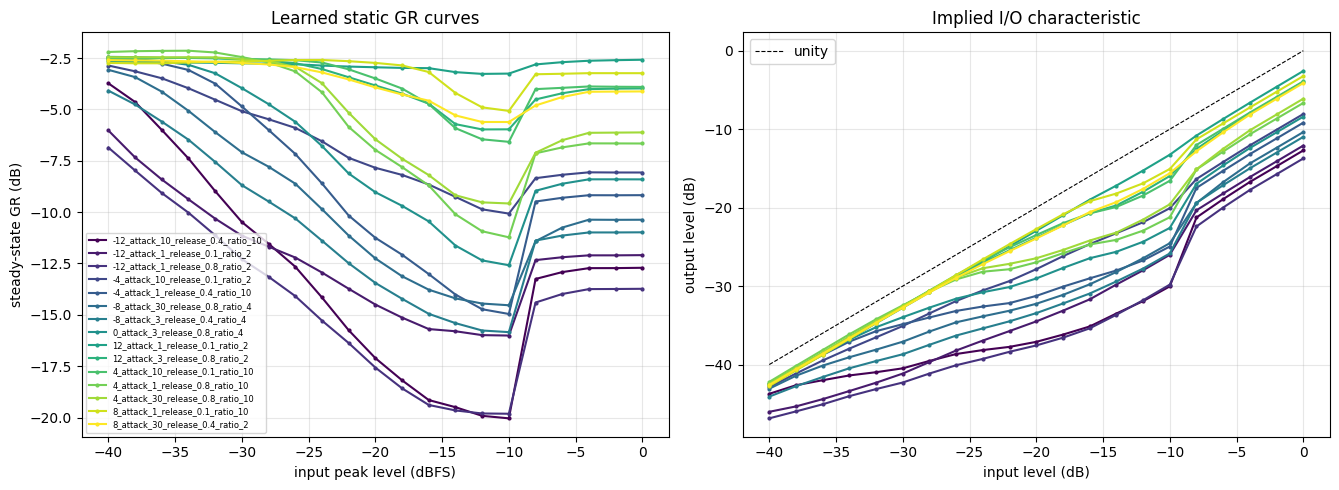

In [2]:
# -- 1. Static compression curve per dataset setting ----------------------
# 4 s tone bursts (1 kHz), peak level swept -40..0 dBFS; steady-state GR from
# the final 1.5 s (past the warmup ambiguity and any release transient).

LEVELS = np.arange(-40, 1, 2.0)
F0 = 1000.0

static = {}
for setting in SETTINGS:
    k = params_for(setting)
    static[setting] = np.array([steady_gr(sine(F0, 4.0, lv), k) for lv in LEVELS])
    print(f"{setting:45s} GR @ 0 dBFS = {static[setting][-1]:6.2f} dB")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(SETTINGS)))
for c, setting in zip(cmap, SETTINGS):
    ax1.plot(LEVELS, static[setting], marker=".", ms=4, color=c, label=setting[10:])
    ax2.plot(LEVELS, LEVELS + static[setting], marker=".", ms=4, color=c)
ax1.set_xlabel("input peak level (dBFS)"); ax1.set_ylabel("steady-state GR (dB)")
ax1.set_title("Learned static GR curves"); ax1.grid(alpha=0.3)
ax1.legend(fontsize=6, loc="lower left")
ax2.plot(LEVELS, LEVELS, "k--", lw=0.8, label="unity")
ax2.set_xlabel("input level (dB)"); ax2.set_ylabel("output level (dB)")
ax2.set_title("Implied I/O characteristic"); ax2.grid(alpha=0.3); ax2.legend()
fig.tight_layout()
fig.savefig(OUT / "03_static_curves.png", dpi=150, bbox_inches="tight")
plt.show()

,setting,thr (label),thr̂ (dBFS),ratio (label),ratiô,compressed pts
0,threshold_-12_attack_10_release_0.4_ratio_10,-12.0,-70.78,10.0,1.35,21
1,threshold_-12_attack_1_release_0.1_ratio_2,-12.0,-104.09,2.0,1.17,21
2,threshold_-12_attack_1_release_0.8_ratio_2,-12.0,-94.28,2.0,1.24,21
5,threshold_-8_attack_30_release_0.8_ratio_4,-8.0,-62.61,4.0,1.29,21
6,threshold_-8_attack_3_release_0.4_ratio_4,-8.0,-73.63,4.0,1.25,21
3,threshold_-4_attack_10_release_0.1_ratio_2,-4.0,-63.15,2.0,1.19,21
4,threshold_-4_attack_1_release_0.4_ratio_10,-4.0,-55.00,10.0,1.32,21
7,threshold_0_attack_3_release_0.8_ratio_4,0.0,-53.44,4.0,1.28,21
10,threshold_4_attack_10_release_0.1_ratio_10,4.0,-72.55,10.0,1.07,21
11,threshold_4_attack_1_release_0.8_ratio_10,4.0,-49.86,10.0,1.23,21


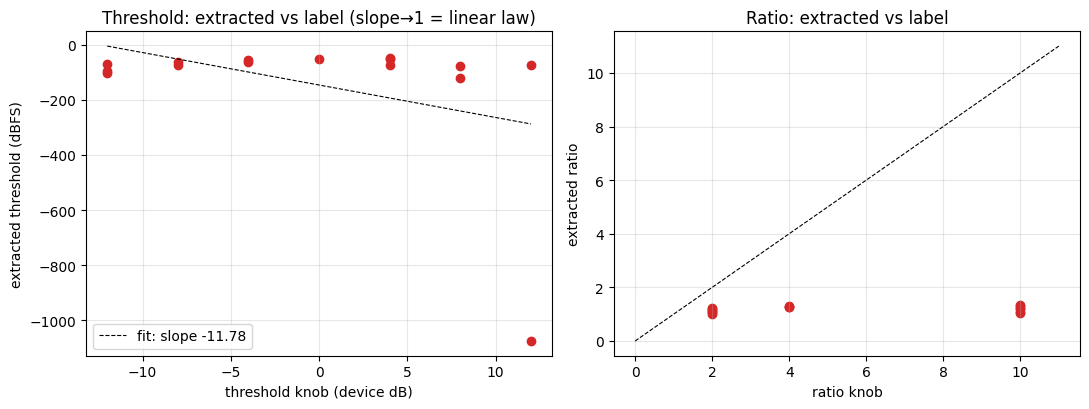

In [3]:
# -- 2. Gain-law extraction: effective ratio and threshold ----------------
# Fit out = a*in + b on the compressed region (points with GR < -1 dB):
# ratio_hat = 1/a; threshold_hat = b/(1-a) (intersection with the unity line).
# Compare against knob labels - RELATIVE comparison (see calibration caveat).

from splits import setting_threshold, DIFFSSL_PARAM_RANGES  # 06_output copy
from src.dsp import parse_settings_from_folder_name

rows = []
for setting in SETTINGS:
    gr = static[setting]
    out_lv = LEVELS + gr
    mask = gr < -1.0
    parsed = parse_settings_from_folder_name(setting)
    if mask.sum() >= 3:
        a, b = np.polyfit(LEVELS[mask], out_lv[mask], 1)
        ratio_hat = 1.0 / a if a > 1e-3 else np.inf
        thr_hat = b / (1.0 - a) if abs(1.0 - a) > 1e-6 else np.nan
    else:
        ratio_hat, thr_hat = np.nan, np.nan
    rows.append({"setting": setting,
                 "thr (label)": float(parsed["threshold"]),
                 "thr̂ (dBFS)": thr_hat,
                 "ratio (label)": float(parsed["ratio"]),
                 "ratiô": ratio_hat,
                 "compressed pts": int(mask.sum())})
law_df = pd.DataFrame(rows).sort_values("thr (label)")
law_df.to_csv(OUT / "03_gain_law_extraction.csv", index=False)
display(law_df.round(2))

ok = law_df.dropna()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.scatter(ok["thr (label)"], ok["thr̂ (dBFS)"], c="#d62728")
a1, b1 = np.polyfit(ok["thr (label)"], ok["thr̂ (dBFS)"], 1)
xs = np.array([ok["thr (label)"].min(), ok["thr (label)"].max()])
ax1.plot(xs, a1 * xs + b1, "k--", lw=0.8, label=f"fit: slope {a1:.2f}")
ax1.set_xlabel("threshold knob (device dB)"); ax1.set_ylabel("extracted threshold (dBFS)")
ax1.grid(alpha=0.3); ax1.legend(); ax1.set_title("Threshold: extracted vs label (slope→1 = linear law)")
ax2.scatter(ok["ratio (label)"], ok["ratiô"], c="#d62728")
lim = max(ok["ratio (label)"].max(), ok["ratiô"].max()) * 1.1
ax2.plot([0, lim], [0, lim], "k--", lw=0.8)
ax2.set_xlabel("ratio knob"); ax2.set_ylabel("extracted ratio")
ax2.grid(alpha=0.3); ax2.set_title("Ratio: extracted vs label")
fig.tight_layout()
fig.savefig(OUT / "03_gain_law_extraction.png", dpi=150, bbox_inches="tight")
plt.show()

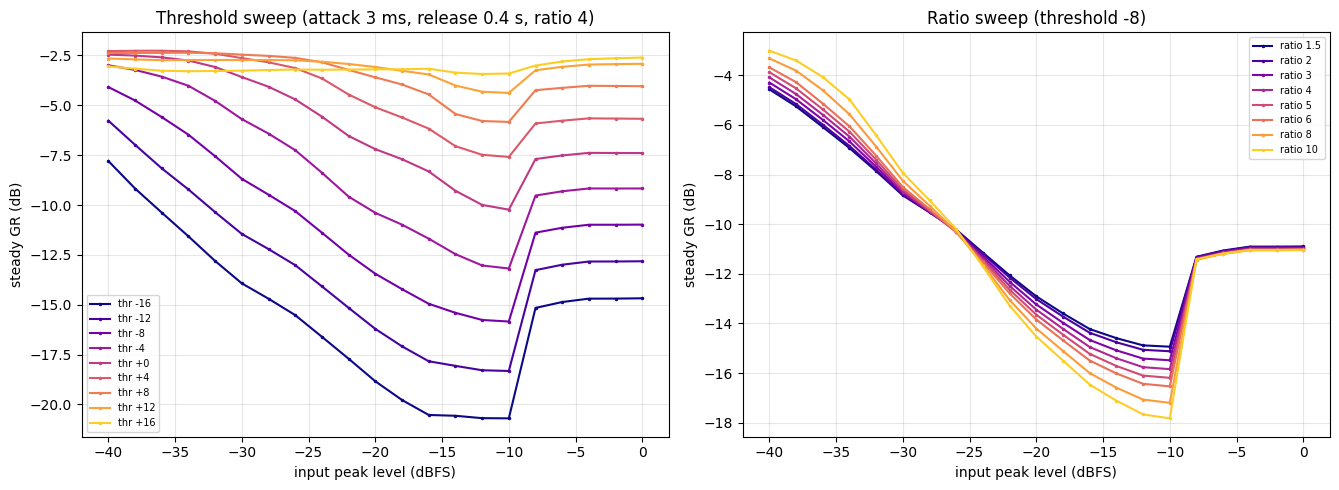

GR @ -6 dBFS vs threshold: [-14.86 -12.99 -11.14  -9.31  -7.51  -5.77  -4.13  -3.07  -2.8 ] 
  monotone non-decreasing: True
GR @ -6 dBFS vs ratio    : [-11.06 -11.08 -11.11 -11.14 -11.16 -11.18 -11.2  -11.18] 
  monotone non-increasing: True


In [4]:
# -- 3. Knob interpolation: unseen knob values ----------------------------
# The 10 training settings sample the knob space sparsely. Sweep threshold and
# ratio through values NOT on that grid: a learned law -> smooth monotone
# family; memorisation -> kinks/plateaus between training values.

THR_SWEEP = np.arange(-16, 17, 4.0)          # training grid: {-12,-8,-4,0,4,8,12}
RATIO_SWEEP = [1.5, 2, 3, 4, 5, 6, 8, 10]    # training grid: {2,4,10}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))
cm1 = plt.cm.plasma(np.linspace(0, 0.9, len(THR_SWEEP)))
curves_thr = {}
for c, thr in zip(cm1, THR_SWEEP):
    k = knobs(thr, 3.0, 0.4, 4.0)
    curves_thr[thr] = np.array([steady_gr(sine(F0, 4.0, lv), k) for lv in LEVELS])
    ax1.plot(LEVELS, curves_thr[thr], color=c, marker=".", ms=3,
             label=f"thr {thr:+.0f}")
ax1.set_xlabel("input peak level (dBFS)"); ax1.set_ylabel("steady GR (dB)")
ax1.set_title("Threshold sweep (attack 3 ms, release 0.4 s, ratio 4)")
ax1.grid(alpha=0.3); ax1.legend(fontsize=7)

cm2 = plt.cm.plasma(np.linspace(0, 0.9, len(RATIO_SWEEP)))
curves_ratio = {}
for c, r in zip(cm2, RATIO_SWEEP):
    k = knobs(-8.0, 3.0, 0.4, r)
    curves_ratio[r] = np.array([steady_gr(sine(F0, 4.0, lv), k) for lv in LEVELS])
    ax2.plot(LEVELS, curves_ratio[r], color=c, marker=".", ms=3, label=f"ratio {r}")
ax2.set_xlabel("input peak level (dBFS)"); ax2.set_ylabel("steady GR (dB)")
ax2.set_title("Ratio sweep (threshold -8)")
ax2.grid(alpha=0.3); ax2.legend(fontsize=7)
fig.tight_layout()
fig.savefig(OUT / "03_knob_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

# monotonicity audit: GR at -6 dBFS as a function of each knob
gr_at = lambda curves, keys: [curves[k][list(LEVELS).index(-6.0)] for k in keys]
thr_vals, ratio_vals = gr_at(curves_thr, THR_SWEEP), gr_at(curves_ratio, RATIO_SWEEP)
print("GR @ -6 dBFS vs threshold:", np.round(thr_vals, 2),
      "\n  monotone non-decreasing:", bool(np.all(np.diff(thr_vals) >= -0.05)))
print("GR @ -6 dBFS vs ratio    :", np.round(ratio_vals, 2),
      "\n  monotone non-increasing:", bool(np.all(np.diff(ratio_vals) <= 0.05)))

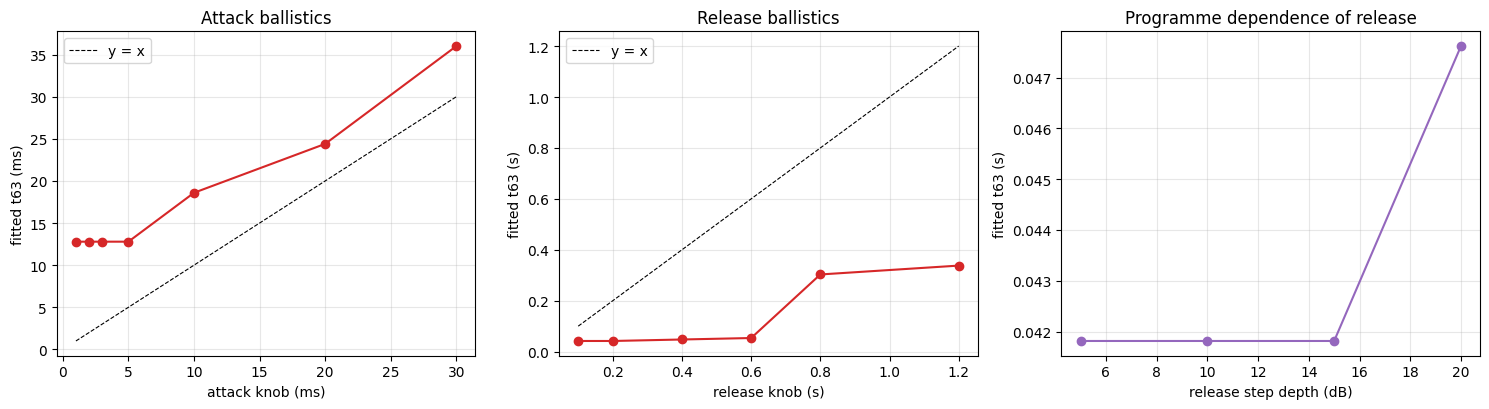

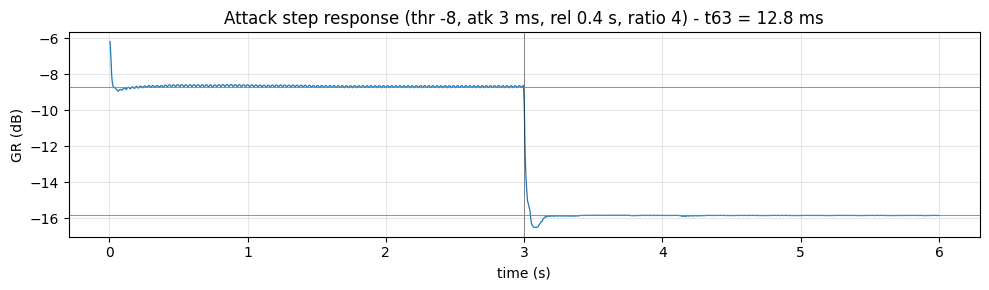

In [5]:
# -- 4. Ballistics: fitted attack / release constants vs knobs ------------
# Level steps -30->-10 dBFS (attack) and -10->-30 (release), 3 s per phase,
# t63 fitted on the GR trajectory after the step. Sweeps include values off
# the training grid (attack grid {1,3,10,30}, release grid {0.1,0.4,0.8}).

ATTACKS = [1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0]
RELEASES = [0.1, 0.2, 0.4, 0.6, 0.8, 1.2]


def step_t63(k, direction):
    if direction == "attack":
        x = level_step(F0, -30.0, -10.0, 3.0, 3.0)
    else:
        x = level_step(F0, -10.0, -30.0, 3.0, 3.0)
    t, gr = probe_gr(x, k)
    pre = gr[(t > 2.5) & (t < 3.0)].mean()
    post = gr[t > 5.5].mean()
    m = t > 3.0
    return fit_t63(t[m] - 3.0, gr[m], pre, post), (t, gr, pre, post)


att_fit = [step_t63(knobs(-8.0, a, 0.4, 4.0), "attack")[0] for a in ATTACKS]
rel_fit = [step_t63(knobs(-8.0, 3.0, r, 4.0), "release")[0] for r in RELEASES]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(ATTACKS, np.array(att_fit) * 1000, "o-", color="#d62728")
axes[0].plot(ATTACKS, ATTACKS, "k--", lw=0.8, label="y = x")
axes[0].set_xlabel("attack knob (ms)"); axes[0].set_ylabel("fitted t63 (ms)")
axes[0].set_title("Attack ballistics"); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(RELEASES, rel_fit, "o-", color="#d62728")
axes[1].plot(RELEASES, RELEASES, "k--", lw=0.8, label="y = x")
axes[1].set_xlabel("release knob (s)"); axes[1].set_ylabel("fitted t63 (s)")
axes[1].set_title("Release ballistics"); axes[1].grid(alpha=0.3); axes[1].legend()

# programme dependence: release t63 vs step DEPTH at fixed knobs (SSL-style
# auto-release would make deeper steps recover differently)
DEPTHS = [-5.0, -10.0, -15.0, -20.0]
dep = []
for d in DEPTHS:
    x = level_step(F0, -10.0, -10.0 + d, 3.0, 3.0)   # step DOWN by |d|
    t, gr = probe_gr(x, knobs(-8.0, 3.0, 0.4, 4.0))
    pre = gr[(t > 2.5) & (t < 3.0)].mean()
    post = gr[t > 5.5].mean()
    m = t > 3.0
    dep.append(fit_t63(t[m] - 3.0, gr[m], pre, post))
axes[2].plot(np.abs(DEPTHS), dep, "o-", color="#9467bd")
axes[2].set_xlabel("release step depth (dB)"); axes[2].set_ylabel("fitted t63 (s)")
axes[2].set_title("Programme dependence of release"); axes[2].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "03_ballistics.png", dpi=150, bbox_inches="tight")
plt.show()

# example trajectory
tau, (t, gr, pre, post) = step_t63(knobs(-8.0, 3.0, 0.4, 4.0), "attack")
plt.figure(figsize=(10, 3))
plt.plot(t, gr, lw=0.9); plt.axvline(3.0, color="k", lw=0.6, alpha=0.5)
plt.axhline(pre, color="gray", lw=0.6); plt.axhline(post, color="gray", lw=0.6)
plt.title(f"Attack step response (thr -8, atk 3 ms, rel 0.4 s, ratio 4) - t63 = {tau*1000:.1f} ms")
plt.xlabel("time (s)"); plt.ylabel("GR (dB)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

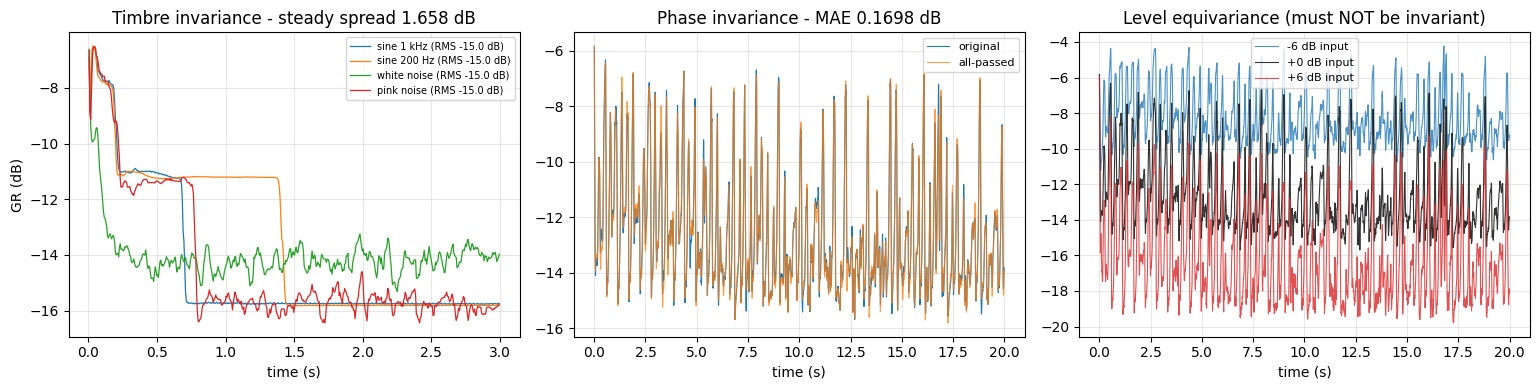

timbre steady-state GR spread : 1.658 dB
phase (all-pass) GR MAE       : 0.1698 dB


In [6]:
# -- 5. Invariance audit ---------------------------------------------------
# (a) timbre: four signals with EQUAL RMS level but different spectra. The
#     detector frontend sees only frame energy, so predictions should collapse;
#     the measured spread is the residual timbre sensitivity of the whole model.
# (b) phase: an all-pass-filtered music excerpt (|H|=1 at all f) must map to
#     the same GR. (c) level equivariance: +-6 dB input shifts should move GR
#     along the static curve, not leave it unchanged.

k = knobs(-8.0, 3.0, 0.4, 4.0)

# (a) timbre
sigs = {
    "sine 1 kHz": sine(1000.0, 3.0, -15.0 + 3.01),     # peak -> approx -15 dB RMS
    "sine 200 Hz": sine(200.0, 3.0, -15.0 + 3.01),
    "white noise": noise(3.0, -15.0, "white"),
    "pink noise": noise(3.0, -15.0, "pink"),
}
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4))
steady = {}
for name, x in sigs.items():
    t, gr = probe_gr(x, k)
    steady[name] = gr[t > 1.5].mean()
    axes[0].plot(t, gr, lw=0.9, label=f"{name} (RMS {rms_dbfs(x):.1f} dB)")
axes[0].set_title(f"Timbre invariance - steady spread "
                  f"{max(steady.values()) - min(steady.values()):.3f} dB")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("GR (dB)")
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7)

# (b) phase: all-pass cascade on a validation-song excerpt
val_pairs = pairs_from_keys(SPLIT.val_pair_keys)
song, setting = val_pairs[0]
dry, _, _ = load_pair(setting, song, start_sec=30.0, duration_sec=20.0)
x = dry[0].numpy()
for a in (0.3, -0.5, 0.7, -0.2):                      # 1st-order allpasses, |H|=1
    x = lfilter([a, 1.0], [1.0, a], x)
dry_ap = torch.from_numpy(x.astype(np.float32)).unsqueeze(0)
t, gr0 = probe_gr(dry, params_for(setting))
_, gr1 = probe_gr(dry_ap, params_for(setting))
axes[1].plot(t, gr0, lw=0.8, label="original")
axes[1].plot(t, gr1, lw=0.8, alpha=0.75, label="all-passed")
axes[1].set_title(f"Phase invariance - MAE {np.abs(gr0 - gr1).mean():.4f} dB")
axes[1].set_xlabel("time (s)"); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

# (c) level equivariance on the same excerpt
for shift, color in ((-6.0, "#1f77b4"), (0.0, "k"), (6.0, "#d62728")):
    _, g = probe_gr(dry * 10 ** (shift / 20), params_for(setting))
    axes[2].plot(t, g, lw=0.8, color=color, alpha=0.8, label=f"{shift:+.0f} dB input")
axes[2].set_title("Level equivariance (must NOT be invariant)")
axes[2].set_xlabel("time (s)"); axes[2].grid(alpha=0.3); axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "03_invariances.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"timbre steady-state GR spread : {max(steady.values()) - min(steady.values()):.3f} dB")
print(f"phase (all-pass) GR MAE       : {np.abs(gr0 - gr1).mean():.4f} dB")

frame encoder : 16 filters x 256 samples (5.8 ms/frame)
temporal stack: receptive field 256 frames = 1.49 s (dilations [1, 4, 16, 64], kernel 4)
detector-bank twin spanned ~2-800 ms with 8 fixed one-poles (for comparison)


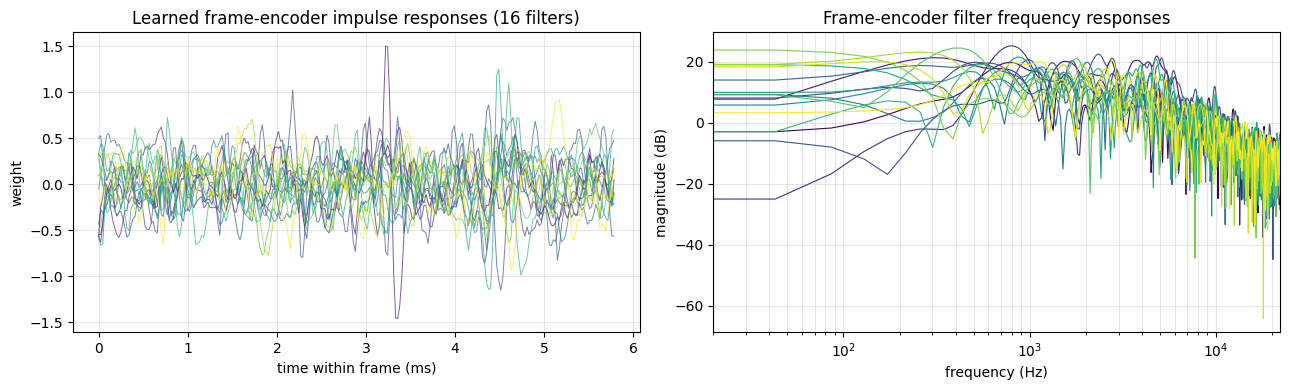

In [7]:
# -- 6. Learned frontend: receptive field + frame-encoder filterbank -------
# The blackbox has no interpretable time constants (unlike the DetectorGRLSTM
# bank's τ's). Its frontend is a learned Conv frame-encoder (stride == hop, so
# one vector per 256-sample frame) followed by a dilated temporal Conv stack.
# Two interpretable readouts:
#  (a) the temporal receptive field of the frame-rate stack — how much past
#      context the level estimate can draw on (compare the detector bank's
#      2–800 ms τ span);
#  (b) the enc_channels frame-encoder filters (each `hop` samples long) shown as
#      impulse + magnitude responses — the within-frame spectral features the
#      model chose to extract. A detector frontend is forced to plain |·|²/energy
#      here; any frequency structure in these filters IS the timbre channel that
#      section 4 then probes end-to-end.

fe = DET.frame_encoder                          # Conv1d(1, enc, kernel=hop, stride=hop)
enc = fe.weight.detach()[:, 0, :].numpy()       # [enc_channels, hop]
n_enc, klen = enc.shape
rf_frames = DET.temporal_context + 1            # frame-rate receptive field (frames)
print(f"frame encoder : {n_enc} filters x {klen} samples ({klen/SR*1000:.1f} ms/frame)")
print(f"temporal stack: receptive field {rf_frames} frames = {rf_frames*HOP/SR:.2f} s "
      f"(dilations {HP['model']['temporal_dilations']}, kernel {HP['model']['temporal_kernel']})")
print(f"detector-bank twin spanned ~2-800 ms with 8 fixed one-poles (for comparison)")

NFFT = 1024
win = np.hanning(klen)
Hf = np.abs(np.fft.rfft(enc * win, n=NFFT, axis=1))
fr = np.fft.rfftfreq(NFFT, 1 / SR)
cmap = plt.cm.viridis(np.linspace(0, 1, n_enc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for i in range(n_enc):
    ax1.plot(np.arange(klen) / SR * 1000, enc[i], lw=0.7, color=cmap[i], alpha=0.7)
ax1.set_xlabel("time within frame (ms)"); ax1.set_ylabel("weight")
ax1.set_title(f"Learned frame-encoder impulse responses ({n_enc} filters)")
ax1.grid(alpha=0.3)
for i in range(n_enc):
    ax2.semilogx(fr, 20 * np.log10(Hf[i] + 1e-6), lw=0.8, color=cmap[i])
ax2.set_xlabel("frequency (Hz)"); ax2.set_ylabel("magnitude (dB)")
ax2.set_title("Frame-encoder filter frequency responses")
ax2.grid(alpha=0.3, which="both"); ax2.set_xlim(20, SR / 2)
fig.tight_layout()
fig.savefig(OUT / "03_frontend_filters.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the results

- **Static curves**: threshold ordering/spacing and ratio steepness should track the
  knobs. The regression slope of extracted-vs-label threshold near 1 means the model
  encodes the threshold *law*, not ten lookup entries. Settings that never compress
  at 0 dBFS (high thresholds) legitimately extract `ratiô ≈ 1`.
- **Interpolation sweeps**: smooth monotone families at unseen knob values are the
  strongest cheap evidence against setting memorisation — quote the monotonicity
  audit directly.
- **Ballistics**: fitted-vs-label scatter on the identity line = the model learned
  attack/release *as functions of the knobs*. Deviations at 1 ms attack are expected:
  one frame is already 5.8 ms, the model's Nyquist for ballistics. The
  programme-dependence panel probes SSL auto-release-like behaviour a fixed
  one-pole ballistics model could not express.
- **Invariances**: because this frontend is *learned* (not the detector's
  by-construction level detector), the timbre spread and all-pass MAE are the direct
  measurement of how much non-level information leaks into its GR estimate — the
  quantity the structural `DetectorGRLSTM` prior forces to zero. Small spread ⇒ the
  blackbox rediscovered a near-level-only law from data; large spread ⇒ it exploits
  timbre and the detector prior is doing real work (this is exactly the val→test
  generalisation trade the two frontends were built to compare). Level equivariance
  is the sanity check that the collapse is not trivial (a constant predictor would
  also be "invariant").
- **Learned frontend**: frequency structure across the frame-encoder filters shows
  the model is reading within-frame *spectral* content, not just energy — the
  mechanism behind any timbre sensitivity measured above; the receptive-field print
  is the blackbox analogue of the detector bank's τ span.